<a href="https://colab.research.google.com/github/PriyaVerma06/EDA-IPL/blob/fix-E6/fix_E6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Issue #5

In [1]:
# 1. Setup and Imports

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 2. Load Data

df = pd.read_csv("https://raw.githubusercontent.com/PriyaVerma06/EDA-IPL/main/data/deliveries.csv")


In [3]:
# 3. Create Total Runs Column

df["total_runs"] = df["batsman_runs"] + df["extra_runs"]


In [5]:
print(df.columns)

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')


In [6]:
# 4. Identify Legal Deliveries
# wides & no-balls are NOT legal deliveries

df["legal_delivery"] = ~df["extras_type"].isin(["wides", "noballs"])

In [7]:
# 5. FILTER POWERPLAY (Overs 1–6)

pp = df[df["over"].between(1, 6)].copy()

# Total runs per bowler
pp_runs = pp.groupby("bowler")["total_runs"].sum()

# Legal balls per bowler
pp_balls = pp[pp["legal_delivery"]].groupby("bowler").size()

# Convert balls → overs
pp_overs = pp_balls / 6

# Economy = runs / overs
pp_economy = (pp_runs / pp_overs).reset_index(name="pp_economy")

In [8]:
# 6. FILTER DEATH OVERS (16–20)

death = df[df["over"].between(16, 20)].copy()

death_runs = death.groupby("bowler")["total_runs"].sum()
death_balls = death[death["legal_delivery"]].groupby("bowler").size()
death_overs = death_balls / 6

death_economy = (death_runs / death_overs).reset_index(name="death_economy")


In [9]:
# 7. Merge Both

merged = pd.merge(pp_economy, death_economy, on="bowler", how="inner")


In [10]:
# 8. Filter Bowlers with ≥20 Overs in BOTH phases

pp_overs_df = pp_overs.reset_index(name="pp_overs")
death_overs_df = death_overs.reset_index(name="death_overs")

merged = merged.merge(pp_overs_df, on="bowler")
merged = merged.merge(death_overs_df, on="bowler")

qualified = merged[
    (merged["pp_overs"] >= 20) &
    (merged["death_overs"] >= 20)
]

print(qualified.head())

        bowler  pp_economy  death_economy    pp_overs  death_overs
5     A Mishra    6.934211       9.846690   76.000000    47.833333
7      A Nehra    7.732350       9.064439  158.166667    69.833333
9     A Nortje    8.540984      10.428571   61.000000    56.000000
10     A Singh    7.170732      10.308725   41.000000    24.833333
17  AB Agarkar    8.948718      10.101266   39.000000    26.333333


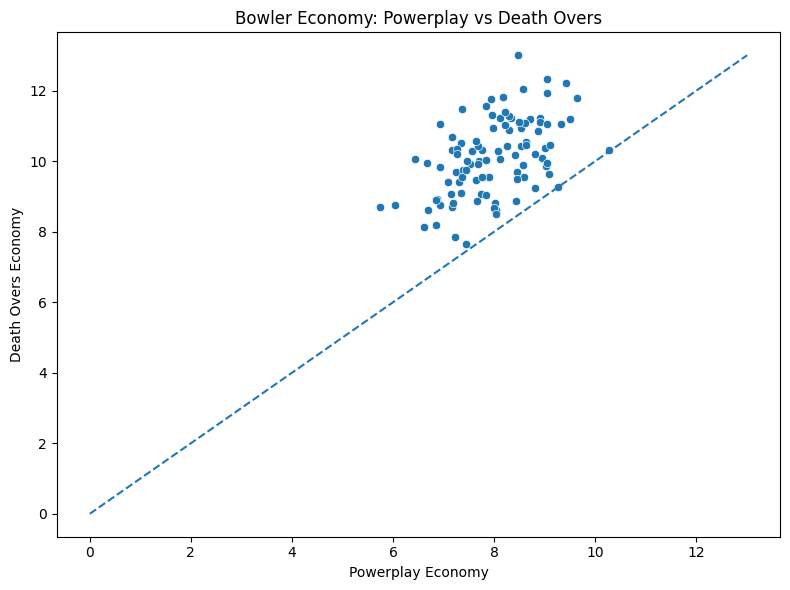

In [11]:
# 9. Visualization (Scatter Plot)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=qualified,
    x="pp_economy",
    y="death_economy"
)

# Diagonal reference line (x = y)
max_val = max(qualified["pp_economy"].max(), qualified["death_economy"].max())
plt.plot([0, max_val], [0, max_val], linestyle="--")

plt.xlabel("Powerplay Economy")
plt.ylabel("Death Overs Economy")
plt.title("Bowler Economy: Powerplay vs Death Overs")

plt.tight_layout()
plt.show()